### RAG with Persistance Memory using LangGraph

In [14]:
# ------------------------------------------------------------
# 1. Web Document, Vector DB, LLM and Embeddings 
# ------------------------------------------------------------

import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_ollama.embeddings import OllamaEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')
os.environ['TAVILY_API_KEY'] = os.getenv('tavily_api_key')

# Url
urls = [
    'https://lilianweng.github.io/posts/2023-06-23-agent/',
    'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
    'https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/'
]

# Web Loader
loader = WebBaseLoader(
    web_path=('https://lilianweng.github.io/posts/2023-06-23-agent/'),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=('post-content', 'post-title', 'post-header')
        )
    )
)

docs = loader.load()

# Splitter
text_splitter = RecursiveCharacterTextSplitter(chunk_size=300, chunk_overlap=50)
doc_split = text_splitter.split_documents(docs)

llm = ChatGroq(model='openai/gpt-oss-120b', max_tokens=1000, temperature=0)
embedding = OllamaEmbeddings(model='nomic-embed-text')

# Vector Store
vector_db = FAISS.from_documents(doc_split, embedding)
vector_retriever = vector_db.as_retriever()

print(f'Vector store created with {vector_db.index.ntotal} vectors')

Vector store created with 214 vectors


In [15]:
from langchain_classic.agents import tool

@tool
def retrieve(query: str) -> str:
    """Retrieve the information related to the query"""
    retrieved_docs = vector_retriever.invoke(query)
    serialized = '\n\n'.join((f'Source: {doc.metadata}\nContent: {doc.page_content}') for doc in retrieved_docs)
    return serialized, retrieved_docs

In [16]:
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode

# Step 1: Generate an AIMessage that may include a tool-call to be sent
def query_or_respond(state: MessagesState):
    """Generate tool call for retrieval or respond."""
    llm_with_tools = llm.bind_tools([retrieve])
    response = llm_with_tools.invoke(state['messages'])
    # MessagesState appends messages to state instead of overwriting
    return {'messages': [response]}

In [17]:
from langgraph.prebuilt import ToolNode

# Step 2: Execute the retrieval
tools = ToolNode([retrieve])

In [18]:
from langchain_core.messages import SystemMessage

# Step 3: Generate a response using the retrieved content

def generate(state: MessagesState):
    """Generate answer."""
    # Get generated ToolMessages
    recent_tool_message = []
    for message in reversed(state['messages']):
        if message.type == 'tool':
            recent_tool_message.append(message)
        else:
            break
    tool_messages = recent_tool_message[::-1]
    
    # Format into prompt
    docs_content = '\n\n'.join(doc.content for doc in tool_messages)
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    
    conversation_messages = [
        message
        for message in state['messages']
        if message.type in ('human', 'system')
        or (message.type == 'ai' and not message.tool_calls)
    ]
    
    prompt = [SystemMessage(system_message_content)] + conversation_messages
    
    # Run
    response = llm.invoke(prompt)
    return {'messages': [response]}

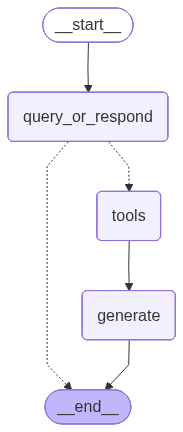

In [19]:
# Build Graph

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

graph_build = StateGraph(MessagesState)

graph_build.add_node(query_or_respond)
graph_build.add_node(tools)
graph_build.add_node(generate)

graph_build.set_entry_point('query_or_respond')
graph_build.add_conditional_edges(
    'query_or_respond',
    tools_condition,
    {END: END, 'tools': 'tools'}
)
graph_build.add_edge('tools', 'generate')
graph_build.add_edge('generate', END)

memory = MemorySaver()

graph = graph_build.compile(checkpointer=memory)
graph

In [20]:
# Specify and ID for the thread
config = {'configurable': {'thread_id': 'aaron1'}}

In [21]:
input_message = 'Hello'

for step in graph.stream(
    {'messages': [{'role': 'user', 'content': input_message}]},
    stream_mode='values',
    config=config
):
    step['messages'][-1].pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I assist you today?


In [22]:
input_message = 'What is task decomposition?'

for step in graph.stream(
    {'messages': [{'role': 'user', 'content': input_message}]},
    stream_mode='values',
    config=config
):
    step['messages'][-1].pretty_print()

================================ Human Message =================================

What is task decomposition?
================================== Ai Message ==================================

**Task decomposition** is the process of breaking a larger, often complex, goal or activity into smaller, more manageable sub‑tasks. By dividing a big problem into discrete pieces, you make it easier to understand, plan, assign, execute, and track progress. The idea is similar to “divide and conquer”: each piece can be tackled independently (or in parallel) and then recombined to achieve the overall objective.

---

## Why Decompose Tasks?

| Benefit | What It Means in Practice |
|---------|----------------------------|
| **Clarity** | You see exactly what needs to be done, which reduces ambiguity. |
| **Estimability** | Smaller pieces are easier to size (time, effort, cost). |
| **Parallelism** | Different people or teams can work on different sub‑tasks simultaneously. |
| **Risk reduction** | Pr

In [ ]:
input_message = 'Can you look up some common ways of doing it?'

for step in graph.stream(
    {'messages': [{'role': 'user', 'content': input_message}]},
    stream_mode='values',
    config=config
):
    step['messages'][-1].pretty_print()

================================ Human Message =================================

Can you look up some common ways of doing it?
================================== Ai Message ==================================
Tool Calls:
  retrieve (fc_82cc7182-fe38-4170-b0eb-327311c7dd62)
 Call ID: fc_82cc7182-fe38-4170-b0eb-327311c7dd62
  Args:
    query: common methods for task decomposition work breakdown structure functional decomposition user story mapping mind mapping
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\nContent: Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\n\nSource: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\nContent: Sub

In [24]:
# Conversation History
chat_history = graph.get_state(config).values['messages']

for message in chat_history:
    message.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I assist you today?
================================ Human Message =================================

What is task decomposition?
================================== Ai Message ==================================

**Task decomposition** is the process of breaking a larger, often complex, goal or activity into smaller, more manageable sub‑tasks. By dividing a big problem into discrete pieces, you make it easier to understand, plan, assign, execute, and track progress. The idea is similar to “divide and conquer”: each piece can be tackled independently (or in parallel) and then recombined to achieve the overall objective.

---

## Why Decompose Tasks?

| Benefit | What It Means in Practice |
|---------|----------------------------|
| **Clarity** | You see exactly what needs to be done, which reduces ambiguit

### ReAct Agent Architecture - Presistant Memory

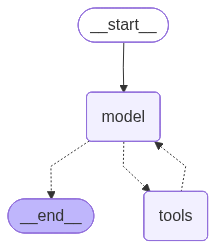

In [27]:
from langgraph.checkpoint.memory import MemorySaver
from langchain.agents import create_agent

memory = MemorySaver()
agent_executor = create_agent(llm, [retrieve], checkpointer=memory)
agent_executor

In [28]:
config = {'configurable': {'thread_id': 'aaron2'}}

In [29]:
input_message = (
    "What is the standard method for task decomposition? \n\n"
    "Once you get the answer, look up common extensions of that method."
)

In [31]:
for event in agent_executor.stream(
    {
        'messages': [{'role': 'user', 'content': input_message}]
    },
    stream_mode='values',
    config=config
):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

What is the standard method for task decomposition? 

Once you get the answer, look up common extensions of that method.
================================== Ai Message ==================================
Tool Calls:
  retrieve (fc_f95cfb1a-f943-4436-a5f8-8d3f86c8676c)
 Call ID: fc_f95cfb1a-f943-4436-a5f8-8d3f86c8676c
  Args:
    query: standard method for task decomposition work breakdown structure extensions product breakdown structure organizational breakdown structure risk breakdown structure
================================= Tool Message =================================
Name: retrieve

('Source: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\nContent: Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\n\nSource: {\'source\': \'https://lilianweng.github.io/posts/2023-06-23-agent/\'}\nConten

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01jydw41w9fkyaqekah9pe9rjf` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8101, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}